In [1]:
import os
os.environ.setdefault("KERAS_BACKEND", "tensorflow")

import numpy as np
from scipy.stats import norm as scipy_norm, invgamma
from scipy.stats import beta as scipy_beta
from scipy.stats import halfnorm
import matplotlib.pyplot as plt
import bayesflow as bf
import keras

np.random.seed(123)
np.set_printoptions(suppress=True)

INFO:bayesflow:Using backend 'tensorflow'


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. Helper functions
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
from scipy.spatial import Delaunay

def _random_adjacency(N):
    """
    Generates a realistic spatial adjacency matrix A 
    using Delaunay Triangulation (planar graph).
    """
    # 1. Drop N random coordinates in a 2D space
    points = np.random.uniform(0, 10, size=(N, 2))
    
    # 2. Compute Delaunay Triangulation (creates non-overlapping triangles)
    tri = Delaunay(points)
    
    # 3. Build the Adjacency Matrix A from the triangle edges
    A = np.zeros((N, N), dtype=int)
    for simplex in tri.simplices:
        # simplex contains the indices of the 3 points forming a triangle
        for i in range(3):
            for j in range(i + 1, 3):
                n1, n2 = simplex[i], simplex[j]
                A[n1, n2] = 1
                A[n2, n1] = 1  # Make it symmetric
                
    return A

def _dagar_factors(A, rho, ordering):
    """
    Compute the DAGAR factors (ImB, lam) without forming Q explicitly.
 
    Q(rho) = (I-B)^T diag(lam) (I-B)
 
    Returns
    -------
    ImB : (n, n)  unit lower-triangular matrix (I - B)
    lam : (n,)    diagonal entries of Lambda
 
    Sampling w ~ N(0, sigma2_w * Q^{-1}) is then done via triangular solve:
        z   ~ N(0, I)
        rhs = sqrt(sigma2_w) * z / sqrt(lam)     [scale by Lambda^{-1/2}]
        w   = solve(ImB, rhs)                     [O(N^2) back-substitution]
    which avoids forming Q or its inverse entirely.
    """
    n    = A.shape[0]
    rho2 = rho ** 2
    inv_order = np.argsort(ordering)
 
    B   = np.zeros((n, n))
    lam = np.zeros(n)
 
    for pos in range(n):
        i     = ordering[pos]
        preds = [ordering[q] for q in range(pos) if A[i, ordering[q]] == 1]
        n_lt  = len(preds)
        denom = 1.0 + max(n_lt - 1, 0) * rho2
        b_val = rho / denom if n_lt > 0 else 0.0
        for j in preds:
            B[pos, inv_order[j]] = b_val
        lam[pos] = denom / (1.0 - rho2)
 
    ImB = np.eye(n) - B   # unit lower-triangular
    return ImB, lam
import warnings

# con rho ed N fissati funziona

ETA_RAW_LOWER = 0.0

# Toggle this flag only for N
USE_FIXED_N = False

ORDERING_MODE = "identity"   # "identity", "random", "x_sorted"

# Used when USE_FIXED_N = True
N_FIXED = 100

# Used when USE_FIXED_N = False
N_MIN = 40
N_MAX = 300

# If you already loaded a fixed adjacency matrix A earlier in the notebook,
# the simulator will use it. Otherwise it will generate a random adjacency.
if "A" in globals():
    A_GLOBAL = np.asarray(A, dtype=np.float32)
    N_FIXED = int(A_GLOBAL.shape[0])
else:
    A_GLOBAL = None
    N_FIXED = 100


def _get_simulation_adjacency(N):
    if A_GLOBAL is not None:
        if A_GLOBAL.shape[0] != N:
            raise ValueError(f"A has shape {A_GLOBAL.shape}, but N={N}.")
        return A_GLOBAL.copy()
    return _random_adjacency(N).astype(np.float32)

"""
def _deterministic_ordering(A):
    # Current recommendation: fixed identity ordering.
    # This matched the clearest eta signal in your diagnostics.
    return np.arange(A.shape[0], dtype=int)
"""

def _get_ordering(A):
    n = A.shape[0]

    if ORDERING_MODE == "random":
        return np.random.permutation(n).astype(int)
    if ORDERING_MODE == "identity":
        return np.arange(n, dtype=int)

    raise ValueError(f"Unknown ORDERING_MODE: {ORDERING_MODE}")

def _repair_isolates_deterministic(A_filtered, A, Z):
    A_rep = A_filtered.copy().astype(np.float32)
    for i in range(A_rep.shape[0]):
        if A_rep[i].sum() == 0:
            neighbors = np.where(A[i] == 1)[0]
            if len(neighbors) > 0:
                # Reconnect to the most similar observed neighbor
                j = neighbors[np.argmin(Z[i, neighbors])]
                A_rep[i, j] = 1.0
                A_rep[j, i] = 1.0
    return A_rep


def _masked_row_mean(values, mask):
    mask_f = mask.astype(np.float32)
    denom = mask_f.sum(axis=1)
    denom_safe = np.where(denom == 0, 1.0, denom)
    out = (values * mask_f).sum(axis=1) / denom_safe
    out[denom == 0] = 0.0
    return out.astype(np.float32)


def _safe_mean_1d(values):
    return float(values.mean()) if values.size > 0 else 0.0
def _safe_corr(x, y):
    x = np.asarray(x, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)

    x_c = x - x.mean()
    y_c = y - y.mean()

    denom = np.sqrt(np.mean(x_c ** 2) * np.mean(y_c ** 2))
    if denom < 1e-8:
        return 0.0
    return float(np.mean(x_c * y_c) / denom)


def _observed_eta_signal_metrics(y, e, A, Z, Z_median, r_lag_all=None):
    A_bool = A == 1
    edge_i, edge_j = np.where(np.triu(A_bool, 1))

    zero_metrics = dict(
        edge_absdiff_low=0.0,
        edge_absdiff_mid=0.0,
        edge_absdiff_high=0.0,
        edge_concord_low=0.0,
        edge_concord_mid=0.0,
        edge_concord_high=0.0,
        edge_absdiff_slope=0.0,
        edge_absdiff_gap=0.0,
        edge_concord_gap=0.0,
        edge_corr_all=0.0,
        lag_corr_all=0.0,
        lag_slope_all=0.0,
        edge_semivar_all=0.0,
        local_moran_mean=0.0,
    )
    if edge_i.size == 0:
        return zero_metrics

    r = (np.log(y + 0.5) - np.log(e)).astype(np.float32)
    z_rel = (Z / Z_median).astype(np.float32)

    z_edge = z_rel[edge_i, edge_j]
    absdiff_edge = np.abs(r[edge_i] - r[edge_j]).astype(np.float32)
    sqdiff_edge = ((r[edge_i] - r[edge_j]) ** 2).astype(np.float32)

    r_centered = (r - r.mean()).astype(np.float32)
    var_r = float(np.mean(r_centered ** 2))
    var_r_safe = max(var_r, 1e-8)

    concord_edge = (r_centered[edge_i] * r_centered[edge_j]).astype(np.float32)

    low = z_edge <= 0.75
    mid = (z_edge > 0.75) & (z_edge <= 1.25)
    high = z_edge > 1.25

    z_bar = float(z_edge.mean())
    absdiff_bar = float(absdiff_edge.mean())
    var_z = float(np.mean((z_edge - z_bar) ** 2))

    if var_z < 1e-8:
        edge_absdiff_slope = 0.0
    else:
        edge_absdiff_slope = float(
            np.mean((z_edge - z_bar) * (absdiff_edge - absdiff_bar)) / var_z
        )

    if r_lag_all is None:
        degree = A_bool.sum(axis=1).astype(np.float32)
        degree_safe = np.where(degree == 0, 1.0, degree)
        W = A / degree_safe[:, None]
        r_lag_all = (W @ r).astype(np.float32)

    r_lag_centered = (r_lag_all - r_lag_all.mean()).astype(np.float32)
    lag_slope_all = float(np.mean(r_centered * r_lag_centered) / var_r_safe)
    lag_corr_all = _safe_corr(r, r_lag_all)

    local_moran = (r_centered * r_lag_all / var_r_safe).astype(np.float32)
    edge_corr_all = float(np.mean(concord_edge) / var_r_safe)
    edge_semivar_all = float(0.5 * np.mean(sqdiff_edge))

    return dict(
        edge_absdiff_low=_safe_mean_1d(absdiff_edge[low]),
        edge_absdiff_mid=_safe_mean_1d(absdiff_edge[mid]),
        edge_absdiff_high=_safe_mean_1d(absdiff_edge[high]),
        edge_concord_low=_safe_mean_1d(concord_edge[low]),
        edge_concord_mid=_safe_mean_1d(concord_edge[mid]),
        edge_concord_high=_safe_mean_1d(concord_edge[high]),
        edge_absdiff_slope=edge_absdiff_slope,
        edge_absdiff_gap=_safe_mean_1d(absdiff_edge[high]) - _safe_mean_1d(absdiff_edge[low]),
        edge_concord_gap=_safe_mean_1d(concord_edge[low]) - _safe_mean_1d(concord_edge[high]),
        edge_corr_all=edge_corr_all,
        lag_corr_all=lag_corr_all,
        lag_slope_all=lag_slope_all,
        edge_semivar_all=edge_semivar_all,
        local_moran_mean=float(local_moran.mean()),
    )


def _build_observed_features(x, y, e, A, Z, Z_median, M):
    A_bool = A == 1

    x = x.astype(np.float32)
    y = y.astype(np.float32)
    e = e.astype(np.float32)

    log_y = np.log1p(y).astype(np.float32)
    log_e = np.log(e).astype(np.float32)
    r = (np.log(y + 0.5) - log_e).astype(np.float32)

    r_centered = (r - r.mean()).astype(np.float32)
    var_r_safe = max(float(np.mean(r_centered ** 2)), 1e-8)

    degree = A_bool.sum(axis=1).astype(np.float32)
    degree_safe = np.where(degree == 0, 1.0, degree)

    z_rel = (Z / Z_median).astype(np.float32)
    neigh_r = np.broadcast_to(r[None, :], z_rel.shape).astype(np.float32)
    abs_r_diff = np.abs(r[:, None] - r[None, :]).astype(np.float32)

    low_mask = A_bool & (z_rel <= 0.75)
    mid_mask = A_bool & (z_rel > 0.75) & (z_rel <= 1.25)
    high_mask = A_bool & (z_rel > 1.25)

    r_lag_all = _masked_row_mean(neigh_r, A_bool)
    absdiff_all = _masked_row_mean(abs_r_diff, A_bool)

    r_lag_low = _masked_row_mean(neigh_r, low_mask)
    r_lag_mid = _masked_row_mean(neigh_r, mid_mask)
    r_lag_high = _masked_row_mean(neigh_r, high_mask)

    absdiff_low = _masked_row_mean(abs_r_diff, low_mask)
    absdiff_mid = _masked_row_mean(abs_r_diff, mid_mask)
    absdiff_high = _masked_row_mean(abs_r_diff, high_mask)

    prop_low = (low_mask.sum(axis=1) / degree_safe).astype(np.float32)
    prop_mid = (mid_mask.sum(axis=1) / degree_safe).astype(np.float32)
    prop_high = (high_mask.sum(axis=1) / degree_safe).astype(np.float32)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        mean_z_rel = np.nanmean(np.where(A_bool, z_rel, np.nan), axis=1)
        max_z_rel = np.nanmax(np.where(A_bool, z_rel, np.nan), axis=1)

    mean_z_rel = np.nan_to_num(mean_z_rel, nan=0.0).astype(np.float32)
    max_z_rel = np.nan_to_num(max_z_rel, nan=0.0).astype(np.float32)

    edge_metrics = _observed_eta_signal_metrics(
        y=y,
        e=e,
        A=A,
        Z=Z,
        Z_median=Z_median,
        r_lag_all=r_lag_all,
    )

    local_moran = (r_centered * r_lag_all / var_r_safe).astype(np.float32)
    local_semivar = (((r - r_lag_all) ** 2) / var_r_safe).astype(np.float32)

    obs = np.stack(
        [
            x,
            #y,
            #e,
            log_y,
            log_e,
            r,
            degree,
            r_lag_all,
            absdiff_all,
            r_lag_low,
            r_lag_mid,
            r_lag_high,
            absdiff_low,
            absdiff_mid,
            absdiff_high,
            prop_low,
            prop_mid,
            prop_high,
            mean_z_rel,
            max_z_rel,
            local_moran,
            local_semivar,
            np.full(len(x), M, dtype=np.float32),
            np.full(len(x), edge_metrics["edge_absdiff_slope"], dtype=np.float32),
            np.full(len(x), edge_metrics["edge_absdiff_gap"], dtype=np.float32),
            np.full(len(x), edge_metrics["edge_concord_gap"], dtype=np.float32),
            np.full(len(x), edge_metrics["edge_corr_all"], dtype=np.float32),
            np.full(len(x), edge_metrics["lag_corr_all"], dtype=np.float32),
            np.full(len(x), edge_metrics["lag_slope_all"], dtype=np.float32),
            np.full(len(x), edge_metrics["edge_semivar_all"], dtype=np.float32),
        ],
        axis=-1,
    )

    return obs.astype(np.float32)

def prior():
    beta_0 = np.random.normal(0.0, 0.5)
    sigma2_w = halfnorm.rvs(scale=0.5)
    eta_raw = np.random.uniform(ETA_RAW_LOWER, 1.0)
    rho = np.random.uniform(0.0, 1.0)
    return dict(
        beta=np.array([beta_0], dtype=np.float32),
        sigma2_w=np.array([sigma2_w], dtype=np.float32),
        eta_raw=np.array([eta_raw], dtype=np.float32),
        rho=np.array([rho], dtype=np.float32),
    )


def likelihood(beta, sigma2_w, eta_raw, rho, N):
    beta_0 = float(beta[0])
    sigma2_w = float(sigma2_w[0])
    eta_raw_val = float(eta_raw[0])
    rho_val = float(rho[0])
    N = int(N)

    A_sim = _get_simulation_adjacency(int(N)).astype(np.float32)

    x = np.random.normal(0.0, 1.0, size=N).astype(np.float32)
    Z = np.abs(x[:, None] - x[None, :]).astype(np.float32)

    Z_edges = Z[A_sim == 1]
    if Z_edges.size == 0:
        Z_median = 1.0
    else:
        Z_median = float(np.median(Z_edges) + 1e-8)

    M = float(np.log(2.0) / Z_median)
    eta = float(eta_raw_val * M)

    A_filtered = A_sim * ((Z * eta) <= np.log(2.0)).astype(np.float32)
    A_filtered = _repair_isolates_deterministic(A_filtered, A_sim, Z)

    ordering = _get_ordering(A_sim)
    
    ImB, dagar_lam = _dagar_factors(A_filtered, rho_val, ordering) #RHO_VAL
    z = np.random.normal(size=N).astype(np.float32)
    rhs = np.sqrt(sigma2_w) * z / np.sqrt(dagar_lam)
    w = np.linalg.solve(ImB, rhs).astype(np.float32)
    w = w - np.mean(w)

    # e = np.random.uniform(50.0, 150.0, size=N).astype(np.float32)
    log_e = np.random.uniform(np.log(2.0), np.log(30000.0), size=N)
    e = np.exp(log_e).astype(np.float32)

    log_poisson_lam = np.log(e) + beta_0 + w
    poisson_lam = np.clip(np.exp(log_poisson_lam), 1e-2, 1e6)
    y = np.random.poisson(poisson_lam).astype(np.float32)

    obs = _build_observed_features(
        x=x,
        y=y,
        e=e,
        A=A_sim,
        Z=Z,
        Z_median=Z_median,
        M=M,
    )

    return dict(
        obs=obs,
        M=np.array([M], dtype=np.float32),
        A=A_sim.astype(np.float32),
        A_filtered=A_filtered.astype(np.float32),
    )


def meta():
    if USE_FIXED_N:
        return dict(N=int(N_FIXED))
    return dict(N=int(np.random.randint(N_MIN, N_MAX + 1)))
simulator = bf.simulators.make_simulator([prior, likelihood], meta_fn=meta)

# Sanity check
sim_draws = simulator.sample(32)
print("Simulator sanity check:")
print("  N             :", sim_draws["N"])
print("  beta     shape:", sim_draws["beta"].shape)
print("  sigma2_w shape:", sim_draws["sigma2_w"].shape)
print("  eta_raw  shape:", sim_draws["eta_raw"].shape)
print("  obs      shape:", sim_draws["obs"].shape)
print("  M        shape:", sim_draws["M"].shape)
print("  A        shape:", sim_draws["A"].shape)
print("  A_filt   shape:", sim_draws["A_filtered"].shape)
print()
# ─────────────────────────────────────────────────────────────────────────────
# 5. Adapter
# ─────────────────────────────────────────────────────────────────────────────

adapter = (
    bf.Adapter()
    .broadcast("N", to="obs")
    .constrain("sigma2_w", lower=0, method="softplus")
    .constrain("eta_raw", lower=0, upper=1, method="sigmoid")
    .constrain("rho", lower=0, upper=1, method="sigmoid")
    .convert_dtype("float64", "float32")
    .concatenate(["beta", "sigma2_w", "eta_raw", "rho"], into="inference_variables")
    .rename("obs", "summary_variables")
    .keep(["inference_variables", "summary_variables", "M", "A", "A_filtered"])
)

processed = adapter(sim_draws)
print("Processed shapes:")
print("  inference_variables :", processed["inference_variables"].shape)
print("  summary_variables   :", processed["summary_variables"].shape)
print()
# ─────────────────────────────────────────────────────────────────────────────
# 4. Networks
# ─────────────────────────────────────────────────────────────────────────────

summary_network = bf.networks.SetTransformer(summary_dim=32) #64

inference_network = bf.networks.CouplingFlow(transform="spline") # num_layers=6, hidden_units=128,
# ─────────────────────────────────────────────────────────────────────────────
# 5. Workflow
# ─────────────────────────────────────────────────────────────────────────────

workflow = bf.BasicWorkflow(
    simulator=simulator,
    adapter=adapter,
    inference_network=inference_network,
    summary_network=summary_network,
    standardize=["inference_variables","summary_variables"]
)

Simulator sanity check:
  N             : 138
  beta     shape: (32, 1)
  sigma2_w shape: (32, 1)
  eta_raw  shape: (32, 1)
  obs      shape: (32, 138, 28)
  M        shape: (32, 1)
  A        shape: (32, 138, 138)
  A_filt   shape: (32, 138, 138)

Processed shapes:
  inference_variables : (32, 4)
  summary_variables   : (32, 138, 28)



In [3]:
import pandas as pd
from pathlib import Path

RESULTS_DIR     = Path("C:/Dati/Lavori/Aiello_Banerjee_2026/Code/ABI_poisson_regression/Simulation Experiments")
IMAGES_DIR      = Path("C:/Dati/Lavori/Aiello_Banerjee_2026/Code/ABI_poisson_regression/Simulation Experiments/Images")
TRAINING_DIR    = Path("C:/Dati/Lavori/Aiello_Banerjee_2026/Code/ABI_poisson_regression/Training")
CHECKPOINTS_DIR = Path("C:/Dati/Lavori/Aiello_Banerjee_2026/Code/ABI_poisson_regression/Training/Checkpoints")

In [4]:
# Reload model
workflow = keras.saving.load_model(str(CHECKPOINTS_DIR / "poisson_dagar.keras"))

# Reload history for loss plot
hist_df = pd.read_csv(TRAINING_DIR / "training_history.csv")

# Reconstruct history-like object for bf.diagnostics.plots.loss()
class FakeHistory:
    def __init__(self, df):
        self.history = df.to_dict(orient="list")

history = FakeHistory(hist_df)

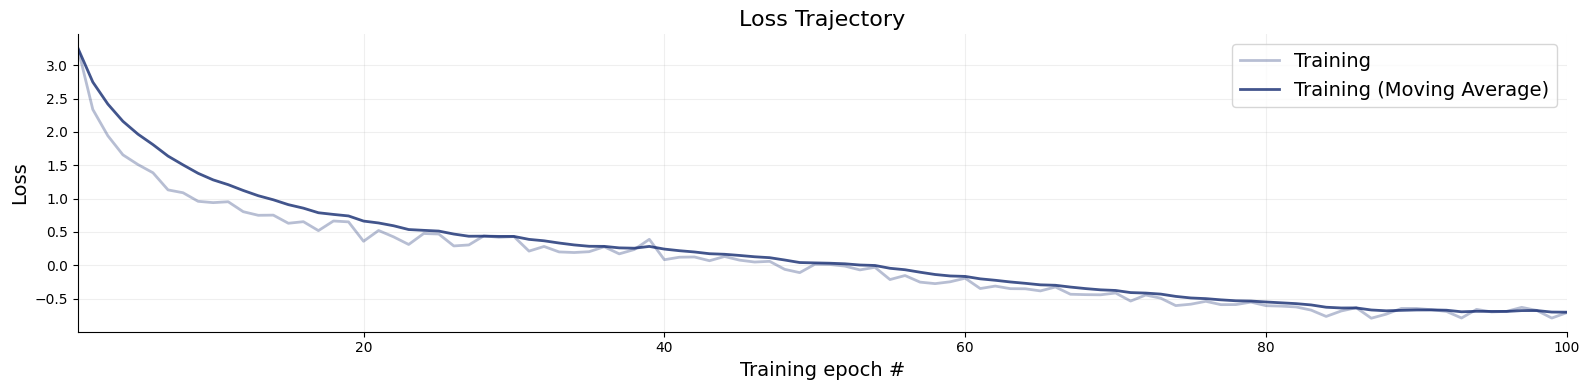

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# 7. Diagnostics
# ─────────────────────────────────────────────────────────────────────────────

plot_param_specs = [
    ("beta", r"$\beta_0$"),
    ("sigma2_w", r"$\sigma^2_w$"),
    ("eta", r"$\eta$"),
    ("rho", r"$\rho$"),
]
plot_keys = [key for key, _ in plot_param_specs]
par_names = [label for _, label in plot_param_specs]#, "mean_deg", "mean_lag", "mean_diff"

# Loss curve
f = bf.diagnostics.plots.loss(history)

In [6]:
np.random.seed(123)
from time import perf_counter


def _sample_heterogeneous_validation_batch(simulator, workflow, n_datasets, num_samples):
    sim_batches = []
    post_batches = []

    validation_t0 = perf_counter()
    for dataset_idx in range(n_datasets):
        sim_i = simulator.sample(1)
        post_i = workflow.sample(conditions=sim_i, num_samples=num_samples)
        sim_batches.append(sim_i)
        post_batches.append(post_i)
    validation_inference_seconds_total = perf_counter() - validation_t0

    N_list = [int(np.asarray(sim_i["obs"]).shape[1]) for sim_i in sim_batches]
    N_max = max(N_list)
    feature_dim = int(np.asarray(sim_batches[0]["obs"]).shape[-1])

    val_sims = {
        "N": np.asarray(N_list, dtype=np.int32)[:, None],
        "obs": np.zeros((n_datasets, N_max, feature_dim), dtype=np.float32),
        "A": np.zeros((n_datasets, N_max, N_max), dtype=np.float32),
        "A_filtered": np.zeros((n_datasets, N_max, N_max), dtype=np.float32),
    }

    for key in ["beta", "sigma2_w", "eta_raw", "rho", "M"]:
        val_sims[key] = np.concatenate(
            [np.asarray(sim_i[key], dtype=np.float32) for sim_i in sim_batches],
            axis=0,
        )

    for idx, sim_i in enumerate(sim_batches):
        obs_i = np.asarray(sim_i["obs"], dtype=np.float32)[0]
        A_i = np.asarray(sim_i["A"], dtype=np.float32)[0]
        A_filt_i = np.asarray(sim_i["A_filtered"], dtype=np.float32)[0]
        N_i = obs_i.shape[0]
        val_sims["obs"][idx, :N_i, :] = obs_i
        val_sims["A"][idx, :N_i, :N_i] = A_i
        val_sims["A_filtered"][idx, :N_i, :N_i] = A_filt_i

    post_draws = {}
    for key in post_batches[0]:
        post_draws[key] = np.concatenate(
            [np.asarray(post_i[key], dtype=np.float32) for post_i in post_batches],
            axis=0,
        )

    return val_sims, post_draws, validation_inference_seconds_total


# Validation
num_samples = 10000
n_validation_datasets = 200
val_sims, post_draws, validation_inference_seconds_total = _sample_heterogeneous_validation_batch(
    simulator=simulator,
    workflow=workflow,
    n_datasets=n_validation_datasets,
    num_samples=num_samples,
)

try:
    import os
    import psutil
    validation_memory_gb = psutil.Process(os.getpid()).memory_info().rss / (1024 ** 3)
except Exception:
    validation_memory_gb = np.nan

print("Posterior keys :", list(post_draws.keys()))
print("beta     shape :", post_draws["beta"].shape)
print("sigma2_w shape :", post_draws["sigma2_w"].shape)
print("rho      shape :", post_draws["rho"].shape)
print("eta_raw  shape :", post_draws["eta_raw"].shape)
print(
    "Validation N summary :",
    {
        "min": int(val_sims["N"].min()),
        "max": int(val_sims["N"].max()),
        "unique": int(np.unique(val_sims["N"]).size),
    },
)
print(f"Validation posterior sampling time (total): {validation_inference_seconds_total:.2f} seconds")
print(f"Validation posterior sampling time (per dataset): {validation_inference_seconds_total / n_validation_datasets:.3f} seconds")
if np.isfinite(validation_memory_gb):
    print(f"Process memory after validation sampling: {validation_memory_gb:.2f} GB")

# Constraint checks
assert (post_draws["sigma2_w"] > 0).all(), "sigma2_w has non-positive samples!"
assert (post_draws["rho"] > 0).all(),      "rho has non-positive samples!"
assert (post_draws["rho"] < 1).all(),      "rho has samples >= 1!"
assert (post_draws["eta_raw"] > 0).all(),  "eta_raw has non-positive samples!"
assert (post_draws["eta_raw"] < 1).all(),  "eta_raw has samples >= 1!"
print("Constraints OK: sigma2_w > 0, rho in (0,1) and eta_raw in (0,1).\n")


Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

...

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Posterior keys : ['beta', 'sigma2_w', 'eta_raw', 'rho']
beta     shape : (200, 10000, 1)
sigma2_w shape : (200, 10000, 1)
rho      shape : (200, 10000, 1)
eta_raw  shape : (200, 10000, 1)
Validation N summary : {'min': 40, 'max': 299, 'unique': 140}
Validation posterior sampling time (total): 163.15 seconds
Validation posterior sampling time (per dataset): 0.816 seconds
Process memory after validation sampling: 0.82 GB
Constraints OK: sigma2_w > 0, rho in (0,1) and eta_raw in (0,1).



In [7]:
eta_raw_samples = post_draws["eta_raw"]      # (D, S, 1)
M_vals          = val_sims["M"]              # (D, 1)

eta_samples = eta_raw_samples * M_vals[:, None, :]

eta_true = val_sims["eta_raw"] * val_sims["M"]   # (D, 1)

post_draws_eta = post_draws.copy()
val_sims_eta   = val_sims.copy()

post_draws_eta["eta"] = eta_samples
val_sims_eta["eta"]   = eta_true

plot_draws = {key: post_draws_eta[key] for key in plot_keys}
plot_targets = {key: val_sims_eta[key] for key in plot_keys}

Recovery plot saved.


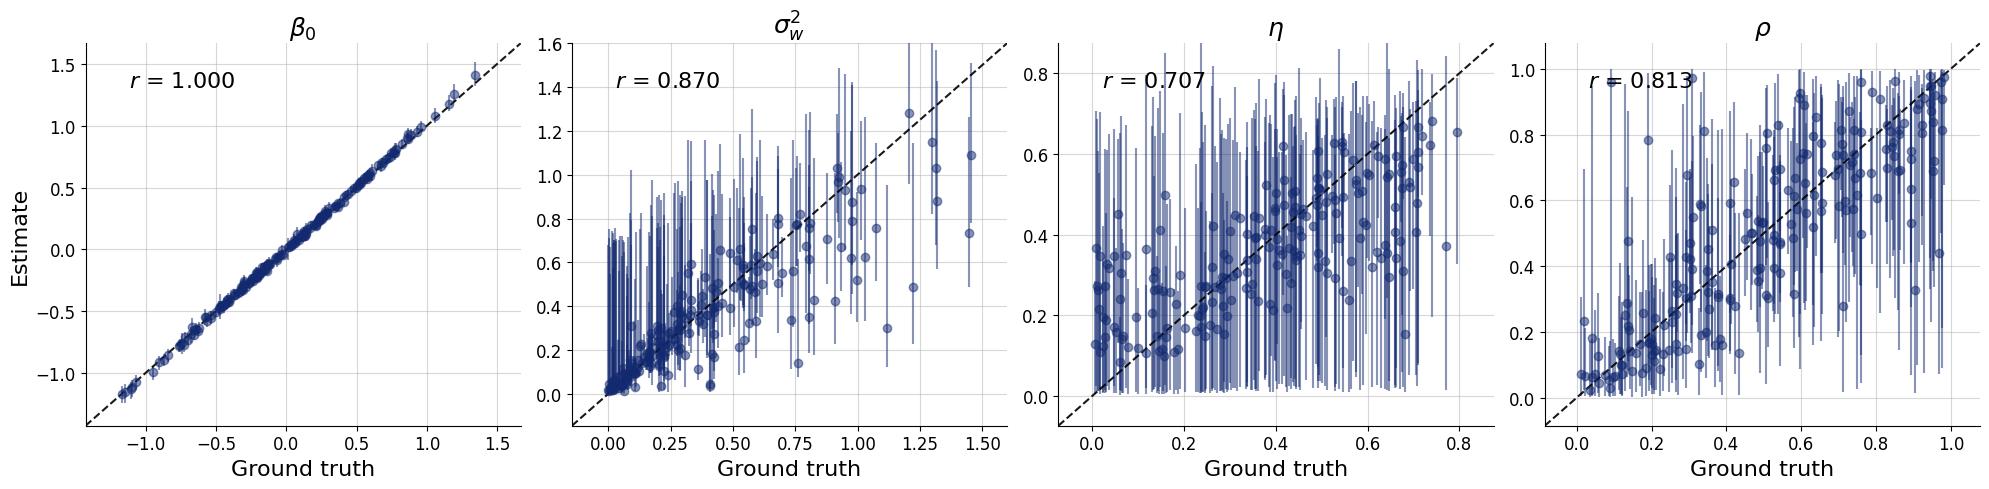

In [8]:
# Recovery
f = bf.diagnostics.plots.recovery(
    estimates=plot_draws,
    targets=plot_targets,
    variable_names=par_names,
)

plt.savefig(IMAGES_DIR/"poisson_dagar_recovery.png",
            dpi=150, bbox_inches="tight")
print("Recovery plot saved.")

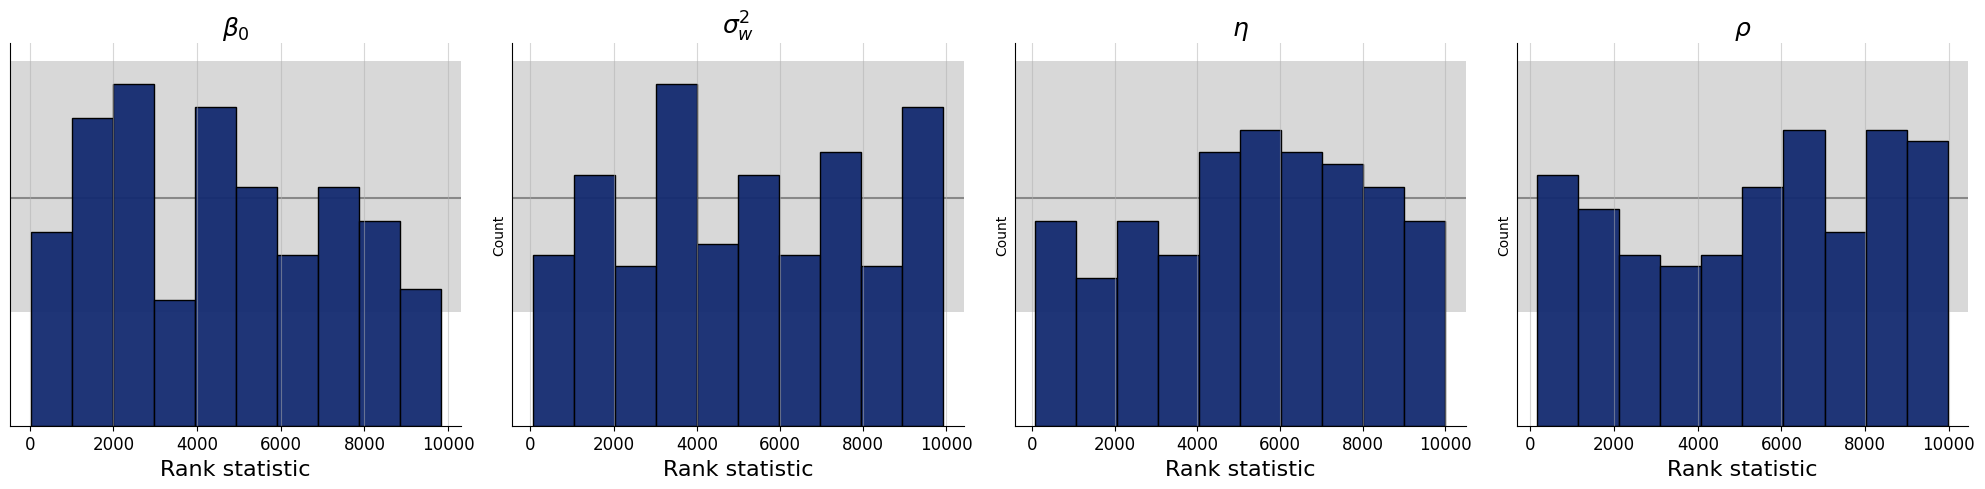

In [9]:
f = bf.diagnostics.plots.calibration_histogram(
    estimates=plot_draws,
    targets=plot_targets,
    variable_names=par_names,
)

plt.savefig(IMAGES_DIR/"poisson_dagar_calibration_histogram.png",
            dpi=150, bbox_inches="tight")

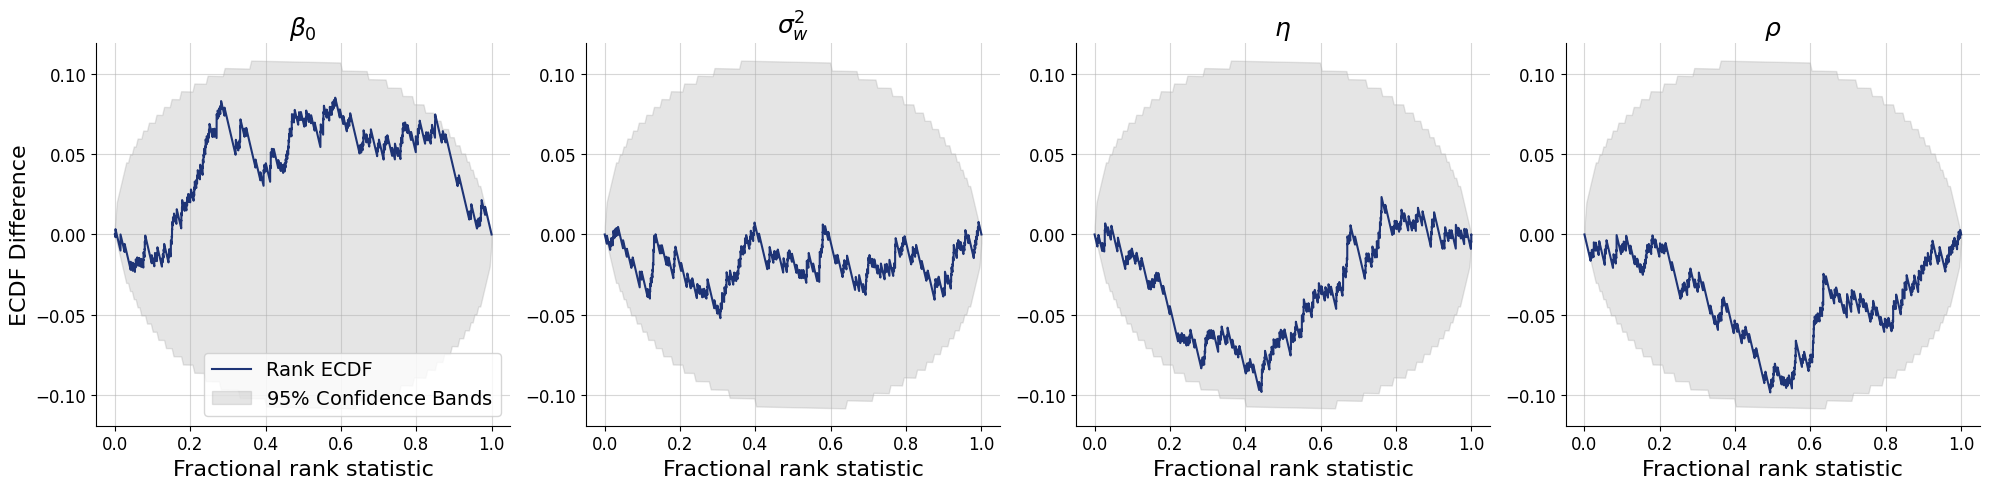

In [10]:
f = bf.diagnostics.plots.calibration_ecdf(
    estimates=plot_draws,
    targets=plot_targets,
    variable_names=par_names,
)

plt.savefig(IMAGES_DIR/"poisson_dagar_calibration_ecdf.png",
            dpi=150, bbox_inches="tight")

In [20]:
import numpy as np

# ─────────────────────────────────────────────────────────────────────────────
# Boundary detection: sensitivity and specificity per validation dataset
# following the FDR approach of the R code
# ─────────────────────────────────────────────────────────────────────────────

alpha_n   = 0.05
N_TEST    = val_sims["A"].shape[0]           # 200 datasets
threshold = np.log(2.0)

sens_list = []
spec_list = []

for idx in range(N_TEST):

    # --- ground truth boundaries ---
    A_true     = val_sims["A"][idx]            # (N, N)
    A_filt     = val_sims["A_filtered"][idx]   # (N, N)
    M_val      = float(val_sims["M"][idx].squeeze())
    x_val      = val_sims["obs"][idx, :, 0]    # x_i is first feature in obs
    N          = A_true.shape[0]

    # edges present in A but removed → true boundaries
    # work on upper triangle only to avoid double counting
    i_idx, j_idx    = np.triu_indices(N, k=1)
    edge_mask       = A_true[i_idx, j_idx] == 1
    i_edges         = i_idx[edge_mask]
    j_edges         = j_idx[edge_mask]

    true_diff = ((A_true[i_edges, j_edges] == 1) &
                 (A_filt[i_edges, j_edges] == 0)).astype(int)   # 1=boundary

    # --- posterior boundary probabilities ---
    # eta_raw posterior samples for this dataset
    eta_raw_post = post_draws["eta_raw"][idx, :, 0]             # (num_samples,)
    eta_post     = eta_raw_post * M_val                          # rescaled
    
    # Z_{ij} for each edge
    Z_edges = np.abs(x_val[i_edges] - x_val[j_edges])           # (n_edges,)

    # for each posterior draw, is this edge a boundary?
    # shape: (num_samples, n_edges)
    boundary_draws = (Z_edges[None, :] * eta_post[:, None]) > threshold

    # posterior probability of boundary per edge
    pvij = boundary_draws.mean(axis=0)                           # (n_edges,)

    # --- FDR-controlled threshold (same as R code) ---
    n_edges     = len(pvij)
    T_edge      = np.arange(1, n_edges + 1)
    sorted_idx  = np.argsort(pvij)[::-1]          # descending order
    pvij_sorted = pvij[sorted_idx]

    # estimated FDR for each possible threshold
    FDR_est = np.zeros(n_edges)
    for t_idx in range(n_edges):
        th          = pvij_sorted[t_idx]
        est_diff    = (pvij >= th).astype(int)
        denom       = est_diff.sum()
        if denom > 0:
            FDR_est[t_idx] = np.sum((1 - pvij) * est_diff) / denom
        else:
            FDR_est[t_idx] = 0.0

    # largest number of boundaries with estimated FDR <= alpha
    T_val = np.sum(FDR_est <= alpha_n)

    if T_val == 0:
        est_diff = np.zeros(n_edges, dtype=int)
    else:
        th_final = pvij_sorted[T_val - 1]
        est_diff = (pvij >= th_final).astype(int)

    # --- sensitivity and specificity ---
    tp = int(((est_diff == 1) & (true_diff == 1)).sum())
    fp = int(((est_diff == 1) & (true_diff == 0)).sum())
    fn = int(((est_diff == 0) & (true_diff == 1)).sum())
    tn = int(((est_diff == 0) & (true_diff == 0)).sum())

    sens = tp / (tp + fn) if (tp + fn) > 0 else np.nan   # true positive rate
    spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan   # true negative rate

    sens_list.append(sens)
    spec_list.append(spec)

sens_arr = np.array(sens_list)
spec_arr = np.array(spec_list)

print(f"Sensitivity — mean: {np.nanmean(sens_arr):.3f}  std: {np.nanstd(sens_arr):.3f}")
print(f"Specificity — mean: {np.nanmean(spec_arr):.3f}  std: {np.nanstd(spec_arr):.3f}")


Sensitivity — mean: 0.169  std: 0.329
Specificity — mean: 0.995  std: 0.016


In [21]:
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────────────────
# Boundary detection: sens/spec curve ranked by number of boundaries selected
# Analogue of the R code sweeping over T_edge = seq(0, n_edges, 1)
# ─────────────────────────────────────────────────────────────────────────────

threshold = np.log(2.0)
N_TEST    = val_sims["A"].shape[0]   # 200 datasets

# Find the maximum number of edges across all datasets to define T_edge grid
n_edges_list = []
for idx in range(N_TEST):
    A_true   = val_sims["A"][idx]
    i_idx, j_idx = np.triu_indices(A_true.shape[0], k=1)
    n_edges_list.append((A_true[i_idx, j_idx] == 1).sum())

T_edge_max = max(n_edges_list)
T_edge     = np.arange(1, T_edge_max + 1)   # 1, 2, ..., max_edges

# sens and spec: shape (N_TEST, T_edge_max)
sens_matrix = np.full((N_TEST, T_edge_max), np.nan)
spec_matrix = np.full((N_TEST, T_edge_max), np.nan)

for idx in range(N_TEST):

    A_true   = val_sims["A"][idx]
    A_filt   = val_sims["A_filtered"][idx]
    M_val    = float(val_sims["M"][idx].squeeze())
    x_val    = val_sims["obs"][idx, :, 0]
    N        = A_true.shape[0]

    i_idx, j_idx = np.triu_indices(N, k=1)
    edge_mask    = A_true[i_idx, j_idx] == 1
    i_edges      = i_idx[edge_mask]
    j_edges      = j_idx[edge_mask]
    n_edges      = edge_mask.sum()

    # true boundary per edge
    true_diff = ((A_true[i_edges, j_edges] == 1) &
                 (A_filt[i_edges, j_edges] == 0)).astype(int)

    # posterior boundary probabilities
    eta_raw_post = post_draws["eta_raw"][idx, :, 0]
    eta_post     = eta_raw_post * M_val

    Z_edges      = np.abs(x_val[i_edges] - x_val[j_edges])
    boundary_draws = (Z_edges[None, :] * eta_post[:, None]) > threshold
    pvij         = boundary_draws.mean(axis=0)            # (n_edges,)

    # rank edges by descending pvij — thresholds for each T
    sorted_pvij  = np.sort(pvij)[::-1]                   # descending

    # sweep over T = 1, ..., n_edges boundaries selected
    for t_idx, T in enumerate(range(1, n_edges + 1)):
        th       = sorted_pvij[T - 1]
        est_diff = (pvij >= th).astype(int)

        tp = int(((est_diff == 1) & (true_diff == 1)).sum())
        fp = int(((est_diff == 1) & (true_diff == 0)).sum())
        fn = int(((est_diff == 0) & (true_diff == 1)).sum())
        tn = int(((est_diff == 0) & (true_diff == 0)).sum())

        sens_matrix[idx, t_idx] = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        spec_matrix[idx, t_idx] = tn / (tn + fp) if (tn + fp) > 0 else np.nan

# Average over datasets (colMeans equivalent)
# Use nanmean to handle datasets with fewer edges than T_edge_max
sens_mean = np.nanmean(sens_matrix, axis=0)   # (T_edge_max,)
spec_mean = np.nanmean(spec_matrix, axis=0)   # (T_edge_max,)


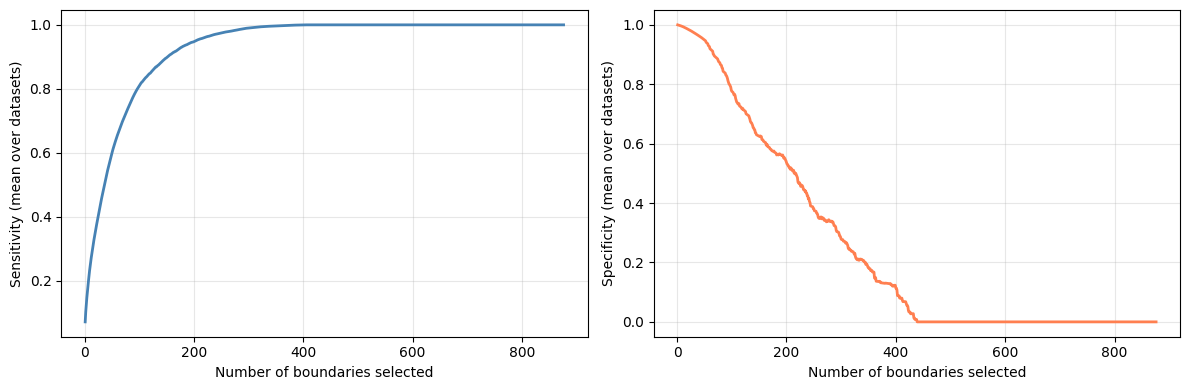

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# Plot — analogue of the R table but as a curve
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# fig.suptitle("Boundary Detection: Sensitivity and Specificity vs Number Selected",
#              fontsize=12, fontweight="bold")

ax = axes[0]
ax.plot(T_edge, sens_mean, color="steelblue", lw=2)
ax.set_xlabel("Number of boundaries selected")
ax.set_ylabel("Sensitivity (mean over datasets)")
# ax.set_title("Sensitivity")
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(T_edge, spec_mean, color="coral", lw=2)
ax.set_xlabel("Number of boundaries selected")
ax.set_ylabel("Specificity (mean over datasets)")
# ax.set_title("Specificity")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(IMAGES_DIR / "boundary_sens_spec_curve.png", dpi=150, bbox_inches="tight")
plt.show()


In [16]:
# ─────────────────────────────────────────────────────────────────────────
# CARBayes-style median probability model: select boundary if PIP > 0.5
# ─────────────────────────────────────────────────────────────────────────

mpm_sens_list = []
mpm_spec_list = []
mpm_selected_list = []
mpm_true_list = []

for idx in range(N_TEST):

    A_true   = val_sims["A"][idx]
    A_filt   = val_sims["A_filtered"][idx]
    M_val    = float(val_sims["M"][idx].squeeze())
    x_val    = val_sims["obs"][idx, :, 0]
    N        = A_true.shape[0]

    i_idx, j_idx = np.triu_indices(N, k=1)
    edge_mask    = A_true[i_idx, j_idx] == 1
    i_edges      = i_idx[edge_mask]
    j_edges      = j_idx[edge_mask]

    true_diff = ((A_true[i_edges, j_edges] == 1) &
                 (A_filt[i_edges, j_edges] == 0)).astype(int)

    eta_raw_post = post_draws["eta_raw"][idx, :, 0]
    eta_post     = eta_raw_post * M_val
    Z_edges      = np.abs(x_val[i_edges] - x_val[j_edges])
    boundary_draws = (Z_edges[None, :] * eta_post[:, None]) > threshold
    pvij         = boundary_draws.mean(axis=0)

    est_diff_mpm = (pvij > 0.5).astype(int)

    tp = int(((est_diff_mpm == 1) & (true_diff == 1)).sum())
    fp = int(((est_diff_mpm == 1) & (true_diff == 0)).sum())
    fn = int(((est_diff_mpm == 0) & (true_diff == 1)).sum())
    tn = int(((est_diff_mpm == 0) & (true_diff == 0)).sum())

    mpm_sens_list.append(tp / (tp + fn) if (tp + fn) > 0 else np.nan)
    mpm_spec_list.append(tn / (tn + fp) if (tn + fp) > 0 else np.nan)
    mpm_selected_list.append(int(est_diff_mpm.sum()))
    mpm_true_list.append(int(true_diff.sum()))

mpm_sens_arr = np.array(mpm_sens_list)
mpm_spec_arr = np.array(mpm_spec_list)
mpm_selected_arr = np.array(mpm_selected_list)
mpm_true_arr = np.array(mpm_true_list)

mpm_results_df = pd.DataFrame({
    "sensitivity": mpm_sens_arr,
    "specificity": mpm_spec_arr,
    "selected_boundaries": mpm_selected_arr,
    "true_boundaries": mpm_true_arr,
})

mpm_summary = pd.DataFrame([
    {"metric": "mean_selected_boundaries", "value": float(mpm_selected_arr.mean())},
    {"metric": "std_selected_boundaries", "value": float(mpm_selected_arr.std())},
    {"metric": "mean_true_boundaries", "value": float(mpm_true_arr.mean())},
    {"metric": "mean_sensitivity", "value": float(np.nanmean(mpm_sens_arr))},
    {"metric": "std_sensitivity", "value": float(np.nanstd(mpm_sens_arr))},
    {"metric": "mean_specificity", "value": float(np.nanmean(mpm_spec_arr))},
    {"metric": "std_specificity", "value": float(np.nanstd(mpm_spec_arr))},
])

print("\nCARBayes-style median probability rule (PIP > 0.5)")
print(mpm_summary.to_string(index=False))

mpm_mean_selected = float(mpm_selected_arr.mean())
mpm_std_selected = float(mpm_selected_arr.std())
mpm_mean_sens = float(np.nanmean(mpm_sens_arr))
mpm_std_sens = float(np.nanstd(mpm_sens_arr))
mpm_mean_spec = float(np.nanmean(mpm_spec_arr))
mpm_std_spec = float(np.nanstd(mpm_spec_arr))

mpm_results_df.to_csv(RESULTS_DIR / "boundary_mpm_results.csv", index=False)
mpm_summary.to_csv(RESULTS_DIR / "boundary_mpm_summary.csv", index=False)



CARBayes-style median probability rule (PIP > 0.5)
                  metric     value
mean_selected_boundaries 80.740000
 std_selected_boundaries 80.344212
    mean_true_boundaries 91.240000
        mean_sensitivity  0.719206
         std_sensitivity  0.322476
        mean_specificity  0.962008
         std_specificity  0.059139


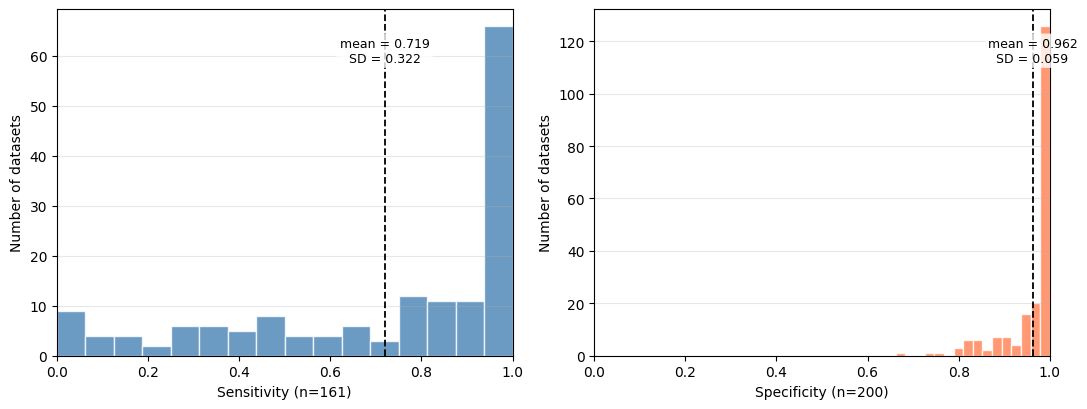

In [17]:
# ─────────────────────────────────────────────────────────────────────────
# Histogram summary for the CARBayes-style median probability rule
# showing the distribution of sensitivity and specificity across datasets
# ─────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
# fig.suptitle("Median Probability Rule: Validation Histograms",
#             fontsize=12, fontweight="bold")

mpm_sens_valid = mpm_sens_arr[np.isfinite(mpm_sens_arr)]
mpm_spec_valid = mpm_spec_arr[np.isfinite(mpm_spec_arr)]

hist_specs = [
    (axes[0], mpm_sens_valid, mpm_mean_sens, mpm_std_sens, f"Sensitivity (n={mpm_sens_valid.size})", "steelblue"),
    (axes[1], mpm_spec_valid, mpm_mean_spec, mpm_std_spec, f"Specificity (n={mpm_spec_valid.size})", "coral"),
]

for ax, values, mean_val, std_val, label, color in hist_specs:
    ax.hist(values, bins=16, color=color, alpha=0.8, edgecolor="white")
    ax.axvline(mean_val, color="black", linestyle="--", linewidth=1.3)
    ax.set_xlim(0, 1.0)
    ax.set_xlabel(label)
    ax.set_ylabel("Number of datasets")
    #ax.set_title(label)
    ax.grid(axis="y", alpha=0.3)
    ymax = ax.get_ylim()[1]
    ax.text(mean_val, ymax * 0.92,
            f"mean = {mean_val:.3f}\nSD = {std_val:.3f}",
            ha="center", va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8, edgecolor="none"))

plt.tight_layout()
plt.savefig(IMAGES_DIR / "boundary_mpm_histograms.png", dpi=150, bbox_inches="tight")
plt.show()


In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# Save — equivalent of the R table (colMeans)
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd

df = pd.DataFrame({
    "T_edge"        : T_edge,
    "sensitivity"   : sens_mean,
    "specificity"   : spec_mean,
})

print(df.head(10).to_string(index=False))
print(df.iloc[::50].to_string(index=False))

 T_edge  sensitivity  specificity
      1     0.071734     0.999520
      2     0.103267     0.998979
      3     0.126164     0.998425
      4     0.147329     0.997806
      5     0.165727     0.997204
      6     0.182748     0.996564
      7     0.199685     0.995914
      8     0.216694     0.995280
      9     0.231722     0.994504
     10     0.245519     0.993778
 T_edge  sensitivity  specificity
      1     0.071734     0.999520
     51     0.606282     0.947218
    101     0.812376     0.774396
    151     0.899097     0.623620
    201     0.948327     0.530898
    251     0.975393     0.373964
    301     0.990594     0.277471
    351     0.996862     0.179138
    401     0.999915     0.113265
    451     1.000000     0.000000
    501     1.000000     0.000000
    551     1.000000     0.000000
    601     1.000000     0.000000
    651     1.000000     0.000000
    701     1.000000     0.000000
    751     1.000000     0.000000
    801     1.000000     0.000000
    851     1.

In [24]:
# -----------------------------------------------------------------------------
# 7b. Comprehensive simulation validation suite: helpers and configuration
# -----------------------------------------------------------------------------
import os
import platform
from time import perf_counter

import pandas as pd
from scipy.stats import spearmanr
from sklearn.metrics import average_precision_score, brier_score_loss, r2_score, roc_auc_score

required_names = [
    "val_sims",
    "post_draws",
    "post_draws_eta",
    "val_sims_eta",
    "_observed_eta_signal_metrics",
    "_get_ordering",
    "_repair_isolates_deterministic",
    "_dagar_factors",
]

missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(
        "Run the earlier simulation-validation cells first. Missing objects: "
        + ", ".join(missing)
    )

SIM_DETAILED_DIR = RESULTS_DIR / "Tables"
SIM_DETAILED_DIR.mkdir(parents=True, exist_ok=True)

TRAINING_TIME_HOURS = 5.74
HARDWARE_NOTE = "Intel(R) Core(TM) i7-10750H CPU @ 2.60GHz (2.59 GHz)"
SIM_PPC_NUM_DRAWS = 100
SIM_PPC_MAX_DATASETS = 40
REFERENCE_PER_DATASET_SECONDS = 3.0  # Fill in when an exact/MCMC benchmark is available.
FLOAT_DECIMALS = 4
FLOAT_FORMAT = f"%.{FLOAT_DECIMALS}f"

PARAM_SPECS = [
    ("beta", "beta_0"),
    ("sigma2_w", "sigma2_w"),
    ("eta", "eta"),
    ("rho", "rho"),
]

PARAM_DISPLAY_MAP = {
    "beta_0": r"$\beta_0$",
    "sigma2_w": r"$\sigma^2_w$",
    "eta": r"$\eta$",
    "rho": r"$\rho$",
}


def _round_df(df, decimals=FLOAT_DECIMALS):
    out = df.copy()
    num_cols = out.select_dtypes(include=[np.number]).columns
    if len(num_cols) > 0:
        out[num_cols] = out[num_cols].round(decimals)
    return out


def _save_rounded_csv(df, path, index=False):
    _round_df(df).to_csv(path, index=index, float_format=FLOAT_FORMAT)


def _print_rounded_df(df, index=False):
    print(_round_df(df).to_string(index=index))


def _safe_true_N(sim_dict, idx):
    if "N" in sim_dict:
        N_value = np.asarray(sim_dict["N"])
        if N_value.ndim == 0:
            return int(N_value.squeeze())
        return int(np.asarray(N_value[idx]).squeeze())
    A_full = np.asarray(sim_dict["A"][idx], dtype=np.float32)
    deg = (A_full > 0.5).sum(axis=1)
    nz = np.where(deg > 0)[0]
    return int(nz.max() + 1) if nz.size > 0 else int(A_full.shape[0])


def _sim_dataset_view(sim_dict, idx):
    N = _safe_true_N(sim_dict, idx)
    A = np.asarray(sim_dict["A"][idx], dtype=np.float32)[:N, :N]
    A_filtered = np.asarray(sim_dict["A_filtered"][idx], dtype=np.float32)[:N, :N]
    obs = np.asarray(sim_dict["obs"][idx], dtype=np.float32)[:N, :]
    M = float(np.asarray(sim_dict["M"][idx]).squeeze())

    x = obs[:, 0].astype(np.float32)
    log_y = obs[:, 1].astype(np.float32)
    log_e = obs[:, 2].astype(np.float32)
    y = np.rint(np.expm1(log_y)).clip(min=0).astype(np.int32)
    e = np.exp(log_e).astype(np.float32)
    Z = np.abs(x[:, None] - x[None, :]).astype(np.float32)

    i_idx, j_idx = np.triu_indices(N, k=1)
    edge_mask = A[i_idx, j_idx] > 0.5
    i_edges = i_idx[edge_mask]
    j_edges = j_idx[edge_mask]
    z_edges = Z[i_edges, j_edges]
    true_boundary = ((A[i_edges, j_edges] > 0.5) & (A_filtered[i_edges, j_edges] < 0.5)).astype(np.int32)

    return dict(
        N=N,
        A=A,
        A_filtered=A_filtered,
        obs=obs,
        x=x,
        y=y,
        e=e,
        Z=Z,
        M=M,
        i_edges=i_edges,
        j_edges=j_edges,
        z_edges=z_edges,
        true_boundary=true_boundary,
        edge_count=int(edge_mask.sum()),
        true_boundary_count=int(true_boundary.sum()),
    )


def _posterior_boundary_info(idx):
    ds = _sim_dataset_view(val_sims, idx)
    eta_raw_post = post_draws["eta_raw"][idx, :, 0].astype(np.float32)
    eta_post = eta_raw_post * ds["M"]
    boundary_draws = (ds["z_edges"][None, :] * eta_post[:, None]) > np.log(2.0)
    pvij = boundary_draws.mean(axis=0).astype(np.float32)
    return ds, eta_post, boundary_draws.astype(np.int8), pvij


def _global_moran_like_from_y(y, e, A):
    r = (np.log(y + 0.5) - np.log(e)).astype(np.float32)
    r_centered = (r - r.mean()).astype(np.float32)
    var_r_safe = max(float(np.mean(r_centered ** 2)), 1e-8)
    degree = (A > 0.5).sum(axis=1).astype(np.float32)
    degree_safe = np.where(degree == 0, 1.0, degree)
    W = A / degree_safe[:, None]
    r_lag = (W @ r).astype(np.float32)
    return float(np.mean(r_centered * r_lag) / var_r_safe)


def _edge_absdiff_triplet(y, e, A, Z):
    edge_mask = A > 0.5
    Z_edges = Z[edge_mask]
    Z_median = float(np.median(Z_edges) + 1e-8) if Z_edges.size > 0 else 1.0
    metrics = _observed_eta_signal_metrics(
        y=y.astype(np.float32),
        e=e.astype(np.float32),
        A=A.astype(np.float32),
        Z=Z.astype(np.float32),
        Z_median=Z_median,
    )
    return np.array(
        [metrics["edge_absdiff_low"], metrics["edge_absdiff_mid"], metrics["edge_absdiff_high"]],
        dtype=np.float32,
    )


def _posterior_predictive_replicates_for_dataset(idx, n_draws=SIM_PPC_NUM_DRAWS):
    ds = _sim_dataset_view(val_sims, idx)
    total_draws = post_draws["beta"].shape[1]
    draw_count = min(int(n_draws), int(total_draws))
    draw_idx = np.linspace(0, total_draws - 1, draw_count, dtype=int)

    y_rep = np.zeros((draw_count, ds["N"]), dtype=np.int32)
    moran_rep = np.zeros(draw_count, dtype=np.float32)
    edge_absdiff_rep = np.zeros((draw_count, 3), dtype=np.float32)

    threshold = np.log(2.0)
    ordering = _get_ordering(ds["A"])

    for out_idx, sample_idx in enumerate(draw_idx):
        beta = float(post_draws["beta"][idx, sample_idx, 0])
        sigma2_w = float(post_draws["sigma2_w"][idx, sample_idx, 0])
        rho = float(post_draws["rho"][idx, sample_idx, 0])
        eta_raw = float(post_draws["eta_raw"][idx, sample_idx, 0])
        eta = eta_raw * ds["M"]

        A_filtered_i = ds["A"] * ((ds["Z"] * eta) <= threshold).astype(np.float32)
        A_filtered_i = _repair_isolates_deterministic(A_filtered_i, ds["A"], ds["Z"])

        ImB, dagar_lam = _dagar_factors(A_filtered_i, rho, ordering)
        z = np.random.normal(size=ds["N"]).astype(np.float32)
        rhs = np.sqrt(max(sigma2_w, 1e-8)) * z / np.sqrt(dagar_lam)
        w = np.linalg.solve(ImB, rhs).astype(np.float32)
        w = w - w.mean()

        lam = np.clip(np.exp(np.log(ds["e"]) + beta + w), 1e-2, 1e6)
        y_draw = np.random.poisson(lam).astype(np.int32)

        y_rep[out_idx] = y_draw
        moran_rep[out_idx] = _global_moran_like_from_y(y_draw, ds["e"], ds["A"])
        edge_absdiff_rep[out_idx] = _edge_absdiff_triplet(y_draw, ds["e"], ds["A"], ds["Z"])

    return dict(
        dataset=ds,
        y_rep=y_rep,
        observed_moran=_global_moran_like_from_y(ds["y"], ds["e"], ds["A"]),
        moran_rep=moran_rep,
        observed_edge_absdiff=_edge_absdiff_triplet(ds["y"], ds["e"], ds["A"], ds["Z"]),
        edge_absdiff_rep=edge_absdiff_rep,
    )


N_TEST = val_sims["A"].shape[0]
N_values = np.array([_safe_true_N(val_sims, idx) for idx in range(N_TEST)], dtype=int)
edge_counts = np.array([_sim_dataset_view(val_sims, idx)["edge_count"] for idx in range(N_TEST)], dtype=int)
eta_true_all = np.asarray(val_sims_eta["eta"]).reshape(N_TEST, -1)[:, 0]
rho_true_all = np.asarray(val_sims_eta["rho"]).reshape(N_TEST, -1)[:, 0]


Parameter recovery summary
parameter   rmse  nrmse_range    bias    mae  rank_correlation     r2  posterior_sd_mean  posterior_median_bias
   beta_0 0.0185       0.0073  0.0025 0.0142            0.9993 0.9986             0.0348                 0.0032
 sigma2_w 0.1639       0.1127 -0.0076 0.1089            0.8891 0.7536             0.1457                -0.0464
      eta 0.1500       0.1897 -0.0202 0.1141            0.7134 0.4909             0.1534                -0.0167
      rho 0.1586       0.1636 -0.0106 0.1150            0.8236 0.6780             0.1371                -0.0021


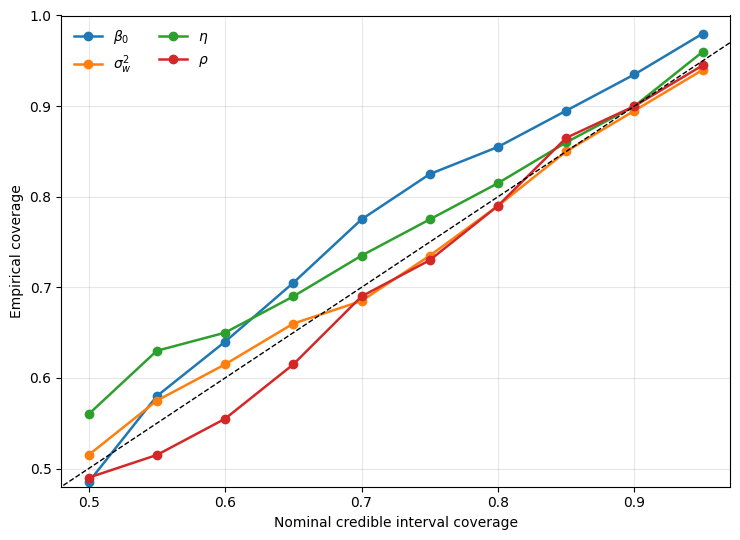

C:\Users\aieie\AppData\Local\Temp\ipykernel_35960\2063316063.py:117: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=graph_size_bin_order, showfliers=False)
C:\Users\aieie\AppData\Local\Temp\ipykernel_35960\2063316063.py:117: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=graph_size_bin_order, showfliers=False)
C:\Users\aieie\AppData\Local\Temp\ipykernel_35960\2063316063.py:117: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=graph_size_bin_order, showfliers=False)
C:\Users\aieie\AppData\Local\Temp\ipykernel_35960\2063316063.py:117: Matplot

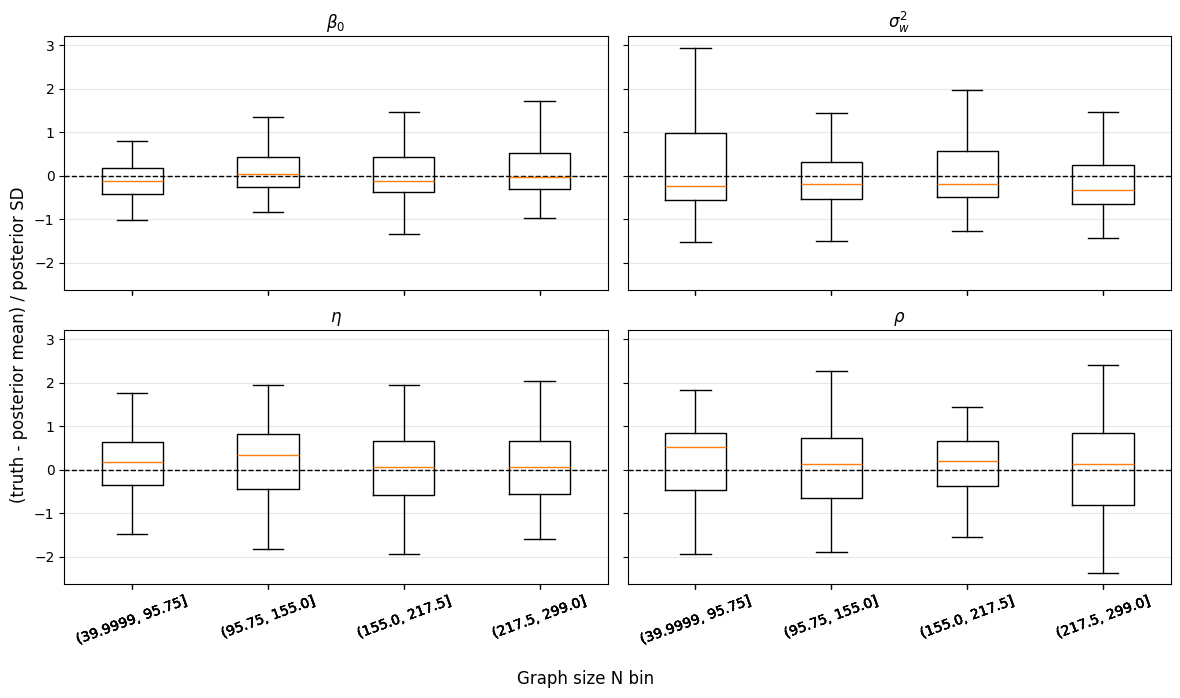

In [25]:
# -----------------------------------------------------------------------------
# 7c. Parameter recovery, empirical coverage, and small-graph discrepancy checks
# -----------------------------------------------------------------------------
parameter_rows = []
recovery_detail = pd.DataFrame({
    "dataset": np.arange(N_TEST, dtype=int),
    "N": N_values,
    "edge_count": edge_counts,
    "true_eta": eta_true_all,
    "true_rho": rho_true_all,
})

for key, label in PARAM_SPECS:
    draws = np.asarray(post_draws_eta[key])[:, :, 0]
    truth = np.asarray(val_sims_eta[key]).reshape(N_TEST, -1)[:, 0]
    post_mean = draws.mean(axis=1)
    post_median = np.median(draws, axis=1)
    post_sd = draws.std(axis=1, ddof=1)
    error = post_mean - truth
    rmse = float(np.sqrt(np.mean(error ** 2)))
    truth_range = max(float(truth.max() - truth.min()), 1e-8)
    bias = float(np.mean(error))
    spearman_val = float(spearmanr(truth, post_mean).correlation)
    r2_val = float(r2_score(truth, post_mean))

    parameter_rows.append({
        "parameter": label,
        "rmse": rmse,
        "nrmse_range": rmse / truth_range,
        "bias": bias,
        "mae": float(np.mean(np.abs(error))),
        "rank_correlation": spearman_val,
        "r2": r2_val,
        "posterior_sd_mean": float(np.mean(post_sd)),
        "posterior_median_bias": float(np.mean(post_median - truth)),
    })

    recovery_detail[f"{label}_error"] = error
    recovery_detail[f"{label}_abs_error"] = np.abs(error)
    recovery_detail[f"{label}_zscore"] = (truth - post_mean) / np.maximum(post_sd, 1e-6)

parameter_summary_df = pd.DataFrame(parameter_rows)
_save_rounded_csv(parameter_summary_df, SIM_DETAILED_DIR / "parameter_recovery_summary.csv", index=False)
_save_rounded_csv(recovery_detail, SIM_DETAILED_DIR / "parameter_recovery_detail.csv", index=False)

print("Parameter recovery summary")
_print_rounded_df(parameter_summary_df, index=False)

nominal_levels = np.array([0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95], dtype=np.float32)
coverage_rows = []
for key, label in PARAM_SPECS:
    draws = np.asarray(post_draws_eta[key])[:, :, 0]
    truth = np.asarray(val_sims_eta[key]).reshape(N_TEST, -1)[:, 0]
    for nominal in nominal_levels:
        alpha = (1.0 - float(nominal)) / 2.0
        lower = np.quantile(draws, alpha, axis=1)
        upper = np.quantile(draws, 1.0 - alpha, axis=1)
        coverage_rows.append({
            "parameter": label,
            "nominal": float(nominal),
            "empirical_coverage": float(np.mean((truth >= lower) & (truth <= upper))),
        })

coverage_df = pd.DataFrame(coverage_rows)
_save_rounded_csv(coverage_df, SIM_DETAILED_DIR / "parameter_coverage_summary.csv", index=False)

fig, ax = plt.subplots(figsize=(7.5, 5.5))
for label in parameter_summary_df["parameter"]:
    sub = coverage_df[coverage_df["parameter"] == label]
    ax.plot(sub["nominal"], sub["empirical_coverage"], marker="o", linewidth=1.8, label=PARAM_DISPLAY_MAP.get(label, label))
ax.plot([0.45, 1.0], [0.45, 1.0], linestyle="--", color="black", linewidth=1.0)
ax.set_xlabel("Nominal credible interval coverage")
ax.set_ylabel("Empirical coverage")
#ax.set_title("Empirical coverage across posterior intervals")
ax.set_xlim(0.48, 0.97)
ax.set_ylim(0.48, 1.00)
ax.grid(alpha=0.3)
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "parameter_coverage_curve.png", dpi=150, bbox_inches="tight")
plt.show()

graph_size_bins = pd.qcut(
    recovery_detail["N"],
    q=min(4, int(recovery_detail["N"].nunique())),
    duplicates="drop",
    precision=4,
)
graph_size_bin_order = [str(x) for x in graph_size_bins.cat.categories]
graph_size_z_df = recovery_detail[["dataset", "N", "edge_count", "true_eta", "true_rho"]].copy()
graph_size_z_df["graph_size_bin"] = graph_size_bins.astype(str)
for _, label in PARAM_SPECS:
    graph_size_z_df[f"{label}_zscore"] = recovery_detail[f"{label}_zscore"]

graph_size_z_long = graph_size_z_df.melt(
    id_vars=["dataset", "N", "edge_count", "true_eta", "true_rho", "graph_size_bin"],
    value_vars=[f"{label}_zscore" for _, label in PARAM_SPECS],
    var_name="parameter",
    value_name="posterior_z",
)
graph_size_z_long["parameter"] = graph_size_z_long["parameter"].str.replace("_zscore", "", regex=False)
_save_rounded_csv(
    graph_size_z_long,
    SIM_DETAILED_DIR / "graph_size_posterior_zscores.csv",
    index=False,
)

fig, axes = plt.subplots(2, 2, figsize=(12, 7.0), sharex=True, sharey=True)
axes = axes.ravel()
param_labels = [label for _, label in PARAM_SPECS]
for ax_idx, (ax, label) in enumerate(zip(axes, param_labels)):
    sub = graph_size_z_long[graph_size_z_long["parameter"] == label]
    box_data = [
        sub.loc[sub["graph_size_bin"] == bin_label, "posterior_z"].dropna().to_numpy()
        for bin_label in graph_size_bin_order
    ]
    ax.boxplot(box_data, labels=graph_size_bin_order, showfliers=False)
    ax.axhline(0.0, color="black", linestyle="--", linewidth=1.0)
    ax.set_title(PARAM_DISPLAY_MAP.get(label, label))
    if ax_idx < 2:
        ax.tick_params(axis="x", labelbottom=False)
    else:
        ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.3)

for ax in axes[len(param_labels):]:
    ax.axis("off")

#fig.suptitle("Posterior z-scores by graph-size bin", fontsize=12, y=1.01)
fig.supxlabel("Graph size N bin")
fig.supylabel("(truth - posterior mean) / posterior SD")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "graph_size_posterior_zscores.png", dpi=150, bbox_inches="tight")
plt.show()


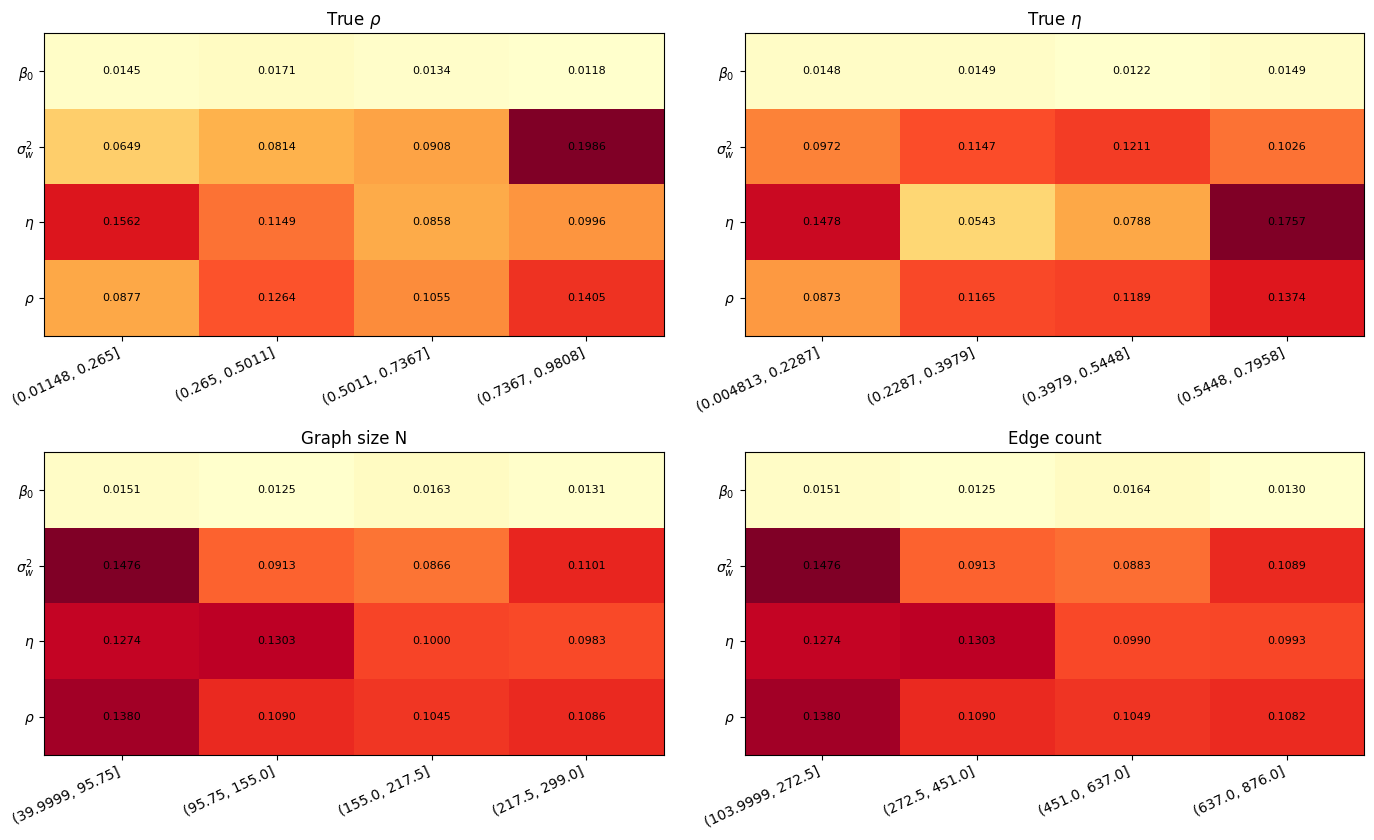

In [26]:
# -----------------------------------------------------------------------------
# 7d. Regime-specific parameter errors by rho, eta, graph size, and edge count
# -----------------------------------------------------------------------------
def _make_qbins(series, q=4):
    series = pd.Series(series)
    q_use = min(q, int(series.nunique()))
    if q_use < 2:
        return pd.Series(["all"] * len(series), index=series.index)
    return pd.qcut(series, q=q_use, duplicates="drop", precision=4)

regime_specs = [
    ("true_rho", r"True $\rho$"),
    ("true_eta", r"True $\eta$"),
    ("N", "Graph size N"),
    ("edge_count", "Edge count"),
]

regime_frames = []
fig, axes = plt.subplots(2, 2, figsize=(14, 8.5))
for ax, (col, title) in zip(axes.ravel(), regime_specs):
    bins = _make_qbins(recovery_detail[col], q=4)
    if hasattr(bins, "cat"):
        ordered_bins = list(bins.cat.categories)
    else:
        ordered_bins = sorted(pd.unique(bins))

    binned = recovery_detail.assign(regime_bin=bins)
    heat = pd.DataFrame(
        {
            label: binned.groupby("regime_bin", observed=False)[f"{label}_abs_error"].mean().reindex(ordered_bins)
            for _, label in PARAM_SPECS
        }
    ).T
    heat = heat.reindex([label for _, label in PARAM_SPECS])

    regime_long = heat.stack().reset_index()
    regime_long.columns = ["parameter", "regime_bin", "mae"]
    regime_long["regime_bin"] = regime_long["regime_bin"].astype(str)
    regime_long["regime_variable"] = col
    regime_frames.append(regime_long)

    image = ax.imshow(heat.to_numpy(dtype=float), aspect="auto", cmap="YlOrRd")
    ax.set_title(title)
    ax.set_xticks(np.arange(heat.shape[1]))
    ax.set_xticklabels([str(x) for x in ordered_bins], rotation=25, ha="right")
    ax.set_yticks(np.arange(heat.shape[0]))
    ax.set_yticklabels([PARAM_DISPLAY_MAP.get(str(x), str(x)) for x in heat.index])
    for row_idx in range(heat.shape[0]):
        for col_idx in range(heat.shape[1]):
            ax.text(col_idx, row_idx, f"{heat.iloc[row_idx, col_idx]:.4f}", ha="center", va="center", fontsize=8)

# fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.85, label="Mean absolute error")
# fig.suptitle("Regime-specific parameter error", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "regime_specific_parameter_errors.png", dpi=150, bbox_inches="tight")
plt.show()

_save_rounded_csv(
    pd.concat(regime_frames, ignore_index=True),
    SIM_DETAILED_DIR / "regime_specific_parameter_errors.csv",
    index=False,
)


Boundary probability summary
                        metric  value
                  pooled_auroc 0.9697
      pooled_average_precision 0.8819
                  pooled_brier 0.0567
            mean_dataset_auroc 0.9955
mean_dataset_average_precision 0.9876
            mean_dataset_brier 0.0612
    boundary_count_coverage_95 0.9950
          fdr_mean_sensitivity 0.1689
          fdr_mean_specificity 0.9953
          mpm_mean_sensitivity 0.7192
          mpm_mean_specificity 0.9620


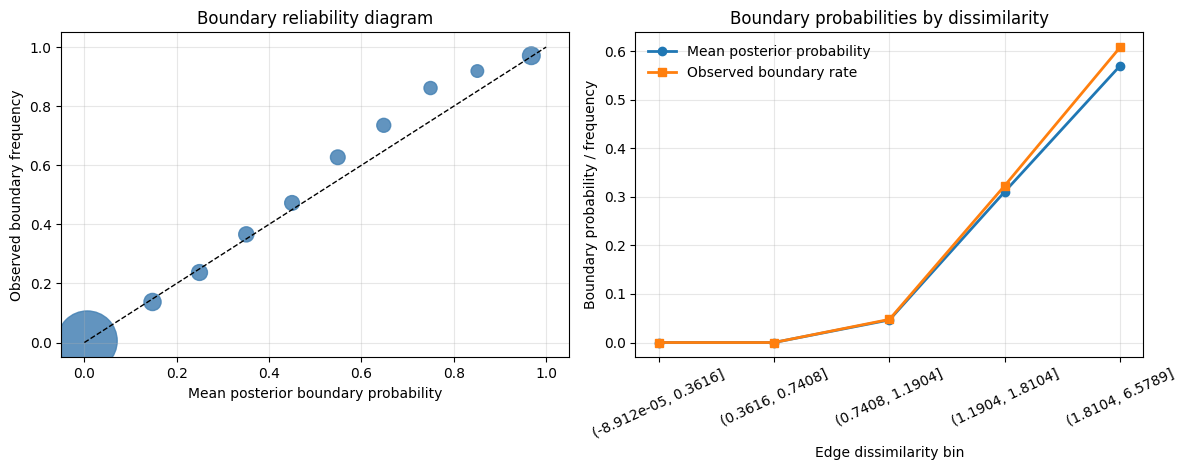

In [27]:
# -----------------------------------------------------------------------------
# 7e. Boundary probability quality: AUROC, PR-AUC, Brier, and calibration
# -----------------------------------------------------------------------------
edge_frames = []
boundary_dataset_rows = []
threshold = np.log(2.0)

for idx in range(N_TEST):
    ds, eta_post, boundary_draws, pvij = _posterior_boundary_info(idx)
    true_boundary = ds["true_boundary"]
    unique_labels = np.unique(true_boundary)

    auroc = float(roc_auc_score(true_boundary, pvij)) if unique_labels.size > 1 else np.nan
    ap = float(average_precision_score(true_boundary, pvij)) if unique_labels.size > 1 else np.nan
    brier = float(brier_score_loss(true_boundary, pvij))

    boundary_count_draws = boundary_draws.sum(axis=1).astype(np.int32)
    count_lower = float(np.quantile(boundary_count_draws, 0.025))
    count_upper = float(np.quantile(boundary_count_draws, 0.975))
    count_ppp = float(np.mean(boundary_count_draws <= ds["true_boundary_count"]))

    boundary_dataset_rows.append({
        "dataset": idx,
        "N": ds["N"],
        "edge_count": ds["edge_count"],
        "true_eta": eta_true_all[idx],
        "true_rho": rho_true_all[idx],
        "true_boundary_count": ds["true_boundary_count"],
        "estimated_boundary_count_mean": float(boundary_count_draws.mean()),
        "estimated_boundary_count_sd": float(boundary_count_draws.std(ddof=1)),
        "boundary_count_covered_95": int(count_lower <= ds["true_boundary_count"] <= count_upper),
        "boundary_count_ppp": count_ppp,
        "auroc": auroc,
        "average_precision": ap,
        "brier": brier,
        "fdr_sensitivity": float(sens_arr[idx]),
        "fdr_specificity": float(spec_arr[idx]),
        "mpm_sensitivity": float(mpm_sens_arr[idx]),
        "mpm_specificity": float(mpm_spec_arr[idx]),
    })

    edge_frames.append(
        pd.DataFrame({
            "dataset": idx,
            "N": ds["N"],
            "edge_count": ds["edge_count"],
            "true_eta": eta_true_all[idx],
            "true_rho": rho_true_all[idx],
            "z_edge": ds["z_edges"],
            "p_boundary": pvij,
            "true_boundary": true_boundary,
        })
    )

boundary_edges_df = pd.concat(edge_frames, ignore_index=True)
boundary_dataset_df = pd.DataFrame(boundary_dataset_rows)

pooled_auroc = float(roc_auc_score(boundary_edges_df["true_boundary"], boundary_edges_df["p_boundary"]))
pooled_ap = float(average_precision_score(boundary_edges_df["true_boundary"], boundary_edges_df["p_boundary"]))
pooled_brier = float(brier_score_loss(boundary_edges_df["true_boundary"], boundary_edges_df["p_boundary"]))

boundary_summary_df = pd.DataFrame([
    {"metric": "pooled_auroc", "value": pooled_auroc},
    {"metric": "pooled_average_precision", "value": pooled_ap},
    {"metric": "pooled_brier", "value": pooled_brier},
    {"metric": "mean_dataset_auroc", "value": float(boundary_dataset_df["auroc"].mean())},
    {"metric": "mean_dataset_average_precision", "value": float(boundary_dataset_df["average_precision"].mean())},
    {"metric": "mean_dataset_brier", "value": float(boundary_dataset_df["brier"].mean())},
    {"metric": "boundary_count_coverage_95", "value": float(boundary_dataset_df["boundary_count_covered_95"].mean())},
    {"metric": "fdr_mean_sensitivity", "value": float(np.nanmean(sens_arr))},
    {"metric": "fdr_mean_specificity", "value": float(np.nanmean(spec_arr))},
    {"metric": "mpm_mean_sensitivity", "value": float(np.nanmean(mpm_sens_arr))},
    {"metric": "mpm_mean_specificity", "value": float(np.nanmean(mpm_spec_arr))},
])

_save_rounded_csv(boundary_summary_df, SIM_DETAILED_DIR / "boundary_probability_summary.csv", index=False)
_save_rounded_csv(boundary_dataset_df, SIM_DETAILED_DIR / "boundary_probability_detail.csv", index=False)
_save_rounded_csv(boundary_edges_df, SIM_DETAILED_DIR / "boundary_probability_edges.csv", index=False)

print("Boundary probability summary")
_print_rounded_df(boundary_summary_df, index=False)

calibration_bins = np.linspace(0.0, 1.0, 11)
boundary_edges_df["prob_bin"] = pd.cut(
    boundary_edges_df["p_boundary"], bins=calibration_bins, include_lowest=True, duplicates="drop"
)
calibration_df = (
    boundary_edges_df.groupby("prob_bin", observed=False)
    .agg(pred_mean=("p_boundary", "mean"), obs_rate=("true_boundary", "mean"), count=("true_boundary", "size"))
    .dropna()
    .reset_index()
)
_save_rounded_csv(calibration_df, SIM_DETAILED_DIR / "boundary_probability_calibration.csv", index=False)

z_bin_df = boundary_edges_df.copy()
z_bin_df["z_bin"] = pd.qcut(z_bin_df["z_edge"], q=5, duplicates="drop", precision=4)
z_profile_df = (
    z_bin_df.groupby("z_bin", observed=False)
    .agg(pred_mean=("p_boundary", "mean"), obs_rate=("true_boundary", "mean"), count=("true_boundary", "size"))
    .dropna()
    .reset_index()
)
_save_rounded_csv(z_profile_df, SIM_DETAILED_DIR / "boundary_probability_dissimilarity_profile.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

ax = axes[0]
ax.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1.0)
ax.scatter(
    calibration_df["pred_mean"],
    calibration_df["obs_rate"],
    s=12 + 0.03 * calibration_df["count"],
    color="steelblue",
    alpha=0.85,
)
ax.set_xlabel("Mean posterior boundary probability")
ax.set_ylabel("Observed boundary frequency")
ax.set_title("Boundary reliability diagram")
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(z_profile_df["z_bin"].astype(str), z_profile_df["pred_mean"], marker="o", linewidth=2, label="Mean posterior probability")
ax.plot(z_profile_df["z_bin"].astype(str), z_profile_df["obs_rate"], marker="s", linewidth=2, label="Observed boundary rate")
ax.set_xlabel("Edge dissimilarity bin")
ax.set_ylabel("Boundary probability / frequency")
ax.set_title("Boundary probabilities by dissimilarity")
ax.tick_params(axis="x", rotation=25)
ax.grid(alpha=0.3)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(IMAGES_DIR / "boundary_probability_quality.png", dpi=150, bbox_inches="tight")
plt.show()


Posterior predictive summary
                        metric    value
             ppc_dataset_count  40.0000
         ppc_draws_per_dataset 100.0000
    node_count_coverage95_mean   0.9388
         moran_coverage95_mean   0.9750
     edge_absdiff_low_ppp_mean   0.5322
     edge_absdiff_mid_ppp_mean   0.4845
    edge_absdiff_high_ppp_mean   0.5397
boundary_count_coverage95_mean   0.9950
           ppc_runtime_seconds  24.5089


C:\Users\aieie\AppData\Local\Temp\ipykernel_35960\431027984.py:86: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(edge_ppp_box, labels=["Low", "Mid", "High"], showfliers=False)


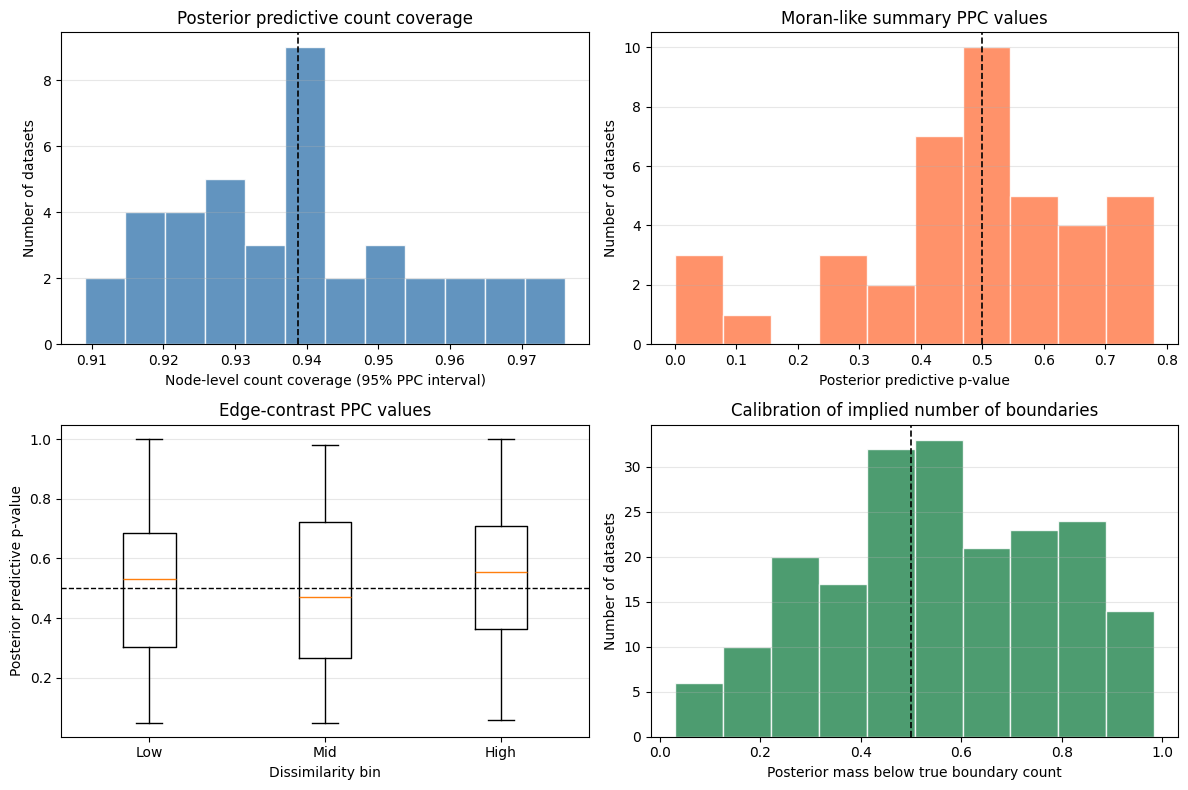

Computation summary
                                  metric      value
                   training_wall_seconds 20664.0000
                     training_wall_hours     5.7400
      validation_inference_seconds_total   163.1504
validation_inference_seconds_per_dataset     0.8158
                    validation_memory_gb     0.8160
                     ppc_runtime_seconds    24.5089
           reference_per_dataset_seconds     3.0000
                     break_even_datasets  9460.4635
                   n_validation_datasets   200.0000
             posterior_draws_per_dataset 10000.0000
Break-even dataset count: 9460.5


In [28]:
# -----------------------------------------------------------------------------
# 7f. Posterior predictive checks and computation summary
# -----------------------------------------------------------------------------
ppc_start = perf_counter()
ppc_sorted = np.argsort(N_values)
ppc_pick = np.unique(np.linspace(0, len(ppc_sorted) - 1, min(SIM_PPC_MAX_DATASETS, len(ppc_sorted)), dtype=int))
ppc_dataset_indices = ppc_sorted[ppc_pick]

ppc_rows = []
for idx in ppc_dataset_indices:
    rep = _posterior_predictive_replicates_for_dataset(int(idx), n_draws=SIM_PPC_NUM_DRAWS)
    ds = rep["dataset"]
    y_rep = rep["y_rep"]

    lower = np.quantile(y_rep, 0.025, axis=0)
    upper = np.quantile(y_rep, 0.975, axis=0)
    count_coverage = float(np.mean((ds["y"] >= lower) & (ds["y"] <= upper)))

    moran_lower = float(np.quantile(rep["moran_rep"], 0.025))
    moran_upper = float(np.quantile(rep["moran_rep"], 0.975))
    moran_ppp = float(np.mean(rep["moran_rep"] <= rep["observed_moran"]))

    obs_edge = rep["observed_edge_absdiff"]
    rep_edge = rep["edge_absdiff_rep"]
    low_ppp = float(np.mean(rep_edge[:, 0] <= obs_edge[0]))
    mid_ppp = float(np.mean(rep_edge[:, 1] <= obs_edge[1]))
    high_ppp = float(np.mean(rep_edge[:, 2] <= obs_edge[2]))

    ppc_rows.append({
        "dataset": int(idx),
        "N": ds["N"],
        "edge_count": ds["edge_count"],
        "node_count_coverage_95": count_coverage,
        "observed_moran": float(rep["observed_moran"]),
        "moran_ppp": moran_ppp,
        "moran_covered_95": int(moran_lower <= rep["observed_moran"] <= moran_upper),
        "edge_absdiff_low_ppp": low_ppp,
        "edge_absdiff_mid_ppp": mid_ppp,
        "edge_absdiff_high_ppp": high_ppp,
    })

ppc_runtime_seconds = perf_counter() - ppc_start
ppc_df = pd.DataFrame(ppc_rows)
_save_rounded_csv(ppc_df, SIM_DETAILED_DIR / "predictive_check_detail.csv", index=False)

predictive_summary_df = pd.DataFrame([
    {"metric": "ppc_dataset_count", "value": float(len(ppc_df))},
    {"metric": "ppc_draws_per_dataset", "value": float(SIM_PPC_NUM_DRAWS)},
    {"metric": "node_count_coverage95_mean", "value": float(ppc_df["node_count_coverage_95"].mean())},
    {"metric": "moran_coverage95_mean", "value": float(ppc_df["moran_covered_95"].mean())},
    {"metric": "edge_absdiff_low_ppp_mean", "value": float(ppc_df["edge_absdiff_low_ppp"].mean())},
    {"metric": "edge_absdiff_mid_ppp_mean", "value": float(ppc_df["edge_absdiff_mid_ppp"].mean())},
    {"metric": "edge_absdiff_high_ppp_mean", "value": float(ppc_df["edge_absdiff_high_ppp"].mean())},
    {"metric": "boundary_count_coverage95_mean", "value": float(boundary_dataset_df["boundary_count_covered_95"].mean())},
    {"metric": "ppc_runtime_seconds", "value": float(ppc_runtime_seconds)},
])
_save_rounded_csv(predictive_summary_df, SIM_DETAILED_DIR / "predictive_check_summary.csv", index=False)

print("Posterior predictive summary")
_print_rounded_df(predictive_summary_df, index=False)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

ax = axes[0, 0]
ax.hist(ppc_df["node_count_coverage_95"], bins=12, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(ppc_df["node_count_coverage_95"].mean(), color="black", linestyle="--", linewidth=1.2)
ax.set_xlabel("Node-level count coverage (95% PPC interval)")
ax.set_ylabel("Number of datasets")
ax.set_title("Posterior predictive count coverage")
ax.grid(axis="y", alpha=0.3)

ax = axes[0, 1]
ax.hist(ppc_df["moran_ppp"], bins=10, color="coral", edgecolor="white", alpha=0.85)
ax.axvline(0.5, color="black", linestyle="--", linewidth=1.2)
ax.set_xlabel("Posterior predictive p-value")
ax.set_ylabel("Number of datasets")
ax.set_title("Moran-like summary PPC values")
ax.grid(axis="y", alpha=0.3)

ax = axes[1, 0]
edge_ppp_box = [
    ppc_df["edge_absdiff_low_ppp"].to_numpy(),
    ppc_df["edge_absdiff_mid_ppp"].to_numpy(),
    ppc_df["edge_absdiff_high_ppp"].to_numpy(),
]
ax.boxplot(edge_ppp_box, labels=["Low", "Mid", "High"], showfliers=False)
ax.axhline(0.5, color="black", linestyle="--", linewidth=1.0)
ax.set_xlabel("Dissimilarity bin")
ax.set_ylabel("Posterior predictive p-value")
ax.set_title("Edge-contrast PPC values")
ax.grid(axis="y", alpha=0.3)

ax = axes[1, 1]
ax.hist(boundary_dataset_df["boundary_count_ppp"], bins=10, color="seagreen", edgecolor="white", alpha=0.85)
ax.axvline(0.5, color="black", linestyle="--", linewidth=1.2)
ax.set_xlabel("Posterior mass below true boundary count")
ax.set_ylabel("Number of datasets")
ax.set_title("Calibration of implied number of boundaries")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(IMAGES_DIR / "predictive_checks.png", dpi=150, bbox_inches="tight")
plt.show()

try:
    import psutil
    current_memory_gb = psutil.Process(os.getpid()).memory_info().rss / (1024 ** 3)
except Exception:
    current_memory_gb = np.nan

training_seconds = float(TRAINING_TIME_HOURS * 3600.0)
validation_seconds = float(globals().get("validation_inference_seconds_total", np.nan))
validation_seconds_per_dataset = validation_seconds / N_TEST if np.isfinite(validation_seconds) else np.nan
memory_gb = float(globals().get("validation_memory_gb", np.nan))
if not np.isfinite(memory_gb):
    memory_gb = current_memory_gb

break_even_datasets = np.nan
if np.isfinite(REFERENCE_PER_DATASET_SECONDS):
    denom = REFERENCE_PER_DATASET_SECONDS - validation_seconds_per_dataset
    if denom > 0:
        break_even_datasets = training_seconds / denom

computation_summary_df = pd.DataFrame([
    {"metric": "training_wall_seconds", "value": training_seconds},
    {"metric": "training_wall_hours", "value": training_seconds / 3600},
    {"metric": "validation_inference_seconds_total", "value": validation_seconds},
    {"metric": "validation_inference_seconds_per_dataset", "value": validation_seconds_per_dataset},
    {"metric": "validation_memory_gb", "value": memory_gb},
    {"metric": "ppc_runtime_seconds", "value": ppc_runtime_seconds},
    {"metric": "reference_per_dataset_seconds", "value": float(REFERENCE_PER_DATASET_SECONDS)},
    {"metric": "break_even_datasets", "value": break_even_datasets},
    {"metric": "n_validation_datasets", "value": float(N_TEST)},
    {"metric": "posterior_draws_per_dataset", "value": float(num_samples)},
])
_save_rounded_csv(computation_summary_df, SIM_DETAILED_DIR / "computation_summary.csv", index=False)

hardware_df = pd.DataFrame([
    {"field": "hardware_note", "value": HARDWARE_NOTE},
    {"field": "platform", "value": platform.platform()},
])
hardware_df.to_csv(SIM_DETAILED_DIR / "hardware_summary.csv", index=False)

print("Computation summary")
_print_rounded_df(computation_summary_df, index=False)
if np.isfinite(break_even_datasets):
    print(f"Break-even dataset count: {break_even_datasets:.1f}")
else:
    print("Break-even dataset count not computed: set REFERENCE_PER_DATASET_SECONDS once a reference benchmark is available.")
